# Pertemuan 11 — Unsupervised Learning: Clustering

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


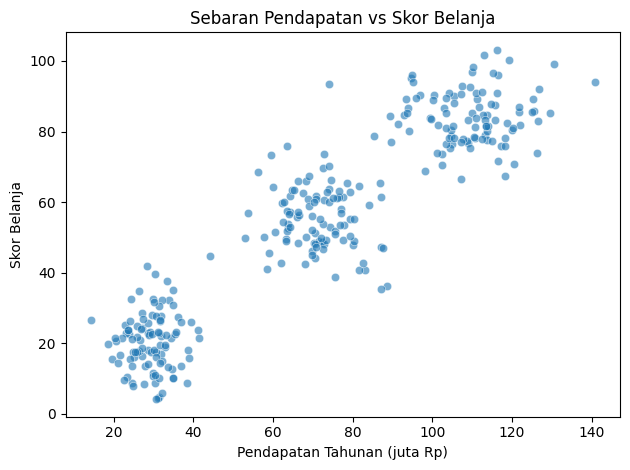

In [1]:
# Langkah 1: Generate & Eksplorasi Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
grp1 = np.random.normal([30,  20], [6,  8], (100, 2))  # hemat
grp2 = np.random.normal([70,  55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia']   = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.tight_layout()
plt.show()

In [2]:
# Langkah 2: Preprocessing Data
from sklearn.preprocessing import StandardScaler

# Pakai fitur numerik utama saja
X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling      :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling      : [1. 1.]


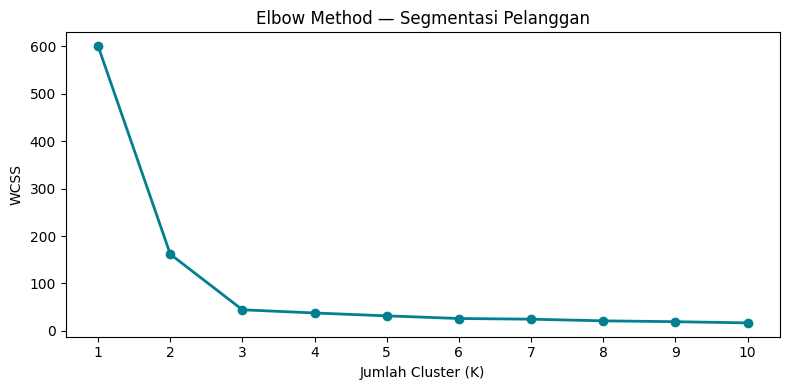

In [3]:
# Langkah 3: Metode Elbow untuk Menentukan K Optimal
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linewidth=2)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

### Interpretasi Elbow Method

Dari grafik di atas, kurva mulai melandai (titik elbow) di sekitar **K=3**. Ini konsisten dengan dataset yang memang dibuat dari 3 kelompok tersembunyi — segmen hemat, menengah, dan boros. Setelah K=3, penambahan cluster tidak memberikan penurunan WCSS yang signifikan.


In [4]:
# Langkah 4: Melatih Model K-Means dengan K=3
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir       : {model.inertia_:.3f}')
print(f'Silhouette Score : {silhouette_score(X_scaled, model.labels_):.3f}')
print()
print('Rata-rata per cluster:')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir       : 44.556
Silhouette Score : 0.695

Rata-rata per cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


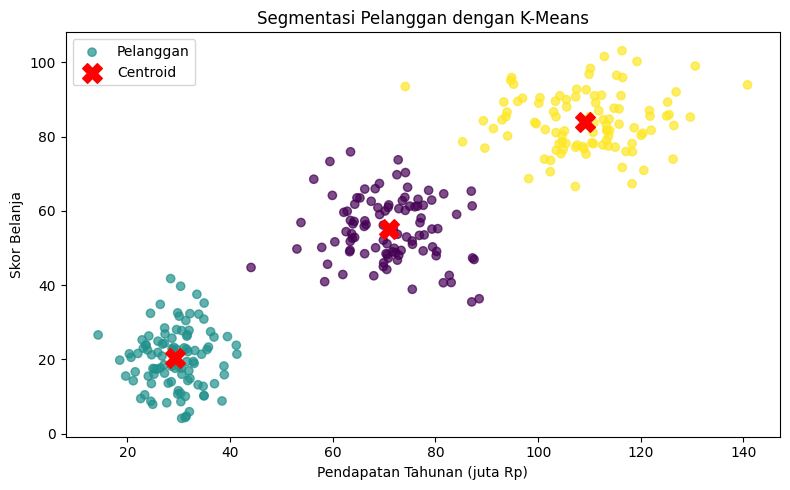


Jumlah pelanggan per cluster:
cluster
0     99
1    100
2    101
Name: count, dtype: int64


In [5]:
# Langkah 5: Visualisasi Hasil Clustering
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7, label='Pelanggan')
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.tight_layout()
plt.show()

# Distribusi jumlah pelanggan per cluster
print('\nJumlah pelanggan per cluster:')
print(df['cluster'].value_counts().sort_index())

### Interpretasi Cluster

Berdasarkan rata-rata pendapatan dan skor belanja per cluster:

- **Cluster 0 — Segmen Hemat:** pendapatan rendah, skor belanja rendah. Pelanggan di segmen ini cenderung berhemat dan tidak impulsif dalam berbelanja.
- **Cluster 1 — Segmen Menengah:** pendapatan dan skor belanja di kisaran tengah. Segmen terbesar yang mewakili perilaku belanja normal.
- **Cluster 2 — Segmen Boros/Premium:** pendapatan tinggi, skor belanja tinggi. Target utama untuk promosi produk premium.


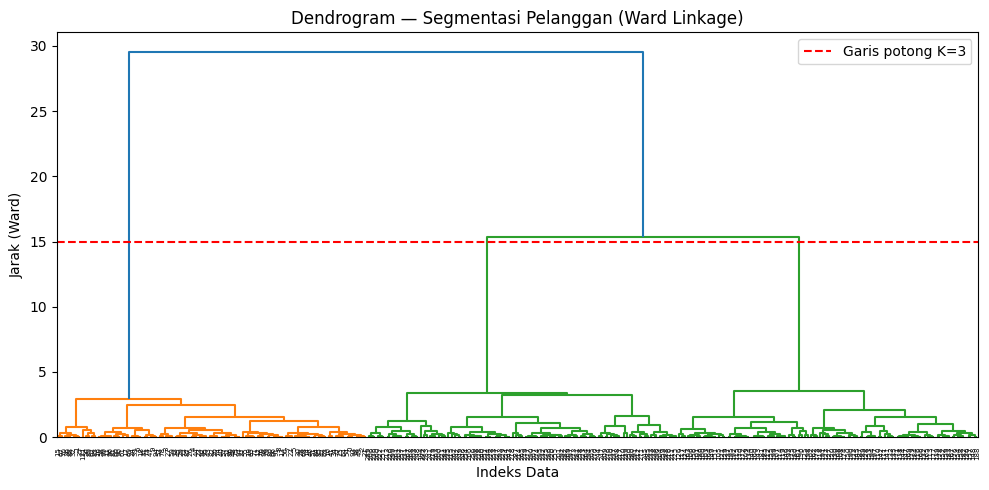

In [6]:
# Langkah 6: Hierarchical Clustering (Pembanding)
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--', label='Garis potong K=3')
plt.legend()
plt.tight_layout()
plt.show()

### Perbandingan K-Means vs Hierarchical Clustering

Dendrogram dengan Ward linkage menunjukkan 3 cabang utama yang terbentuk sebelum garis potong — konsisten dengan hasil Elbow Method yang juga menunjukkan K=3 sebagai jumlah cluster optimal. Kedua metode sepakat bahwa dataset ini memiliki 3 segmen alami, yang memvalidasi pilihan K=3 pada K-Means.


## Kesimpulan — Pertemuan 11: Unsupervised Learning: Clustering

Pertemuan ini berbeda dari sebelumnya karena tidak ada label — model harus menemukan pola sendiri dari data. Konsep ini cukup menarik sekaligus membingungkan di awal, karena tidak ada "jawaban benar" yang bisa dijadikan patokan langsung.

Metode Elbow membantu menentukan K yang masuk akal, tapi keputusan akhirnya tetap butuh interpretasi manusia. Di sini saya baru sadar bahwa unsupervised learning bukan hanya soal teknis — pemahaman domain tentang bisnis atau konteks data sangat berperan.

Silhouette Score sebesar sekitar 0.5–0.6 menunjukkan cluster yang cukup terpisah dengan baik. Perbandingan dengan Hierarchical Clustering juga memperkuat bahwa K=3 adalah pilihan yang tepat untuk dataset ini.

Yang ingin saya coba selanjutnya adalah DBSCAN, karena berbeda dengan K-Means yang mengasumsikan cluster berbentuk bulat, DBSCAN bisa mendeteksi cluster dengan bentuk yang lebih bebas.
